In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_reviews_full.csv")

print(df.head())

        review_id  product_id  \
0  R2SSSH04J4J264  B0D4SX9RC6   
1  R39X7USU3OX34C  B0D4SX9RC6   
2  R1BHCCLK5GZ5VZ  B0D4SX9RC6   
3   R4BQHA0TLLJNN  B0D4SX9RC6   
4  R3SO3HMV0YC0WB  B0D4SX9RC6   

                                        product_name  brand  rating  \
0  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   
1  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   
2  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   
3  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   
4  Beats Pill - Portable Bluetooth Speaker (2024 ...  Beats     5.0   

                                               title  \
0  5.0 out of 5 stars Really nice portable speake...   
1                     5.0 out of 5 stars Really good   
2                      5.0 out of 5 stars Beats Pill   
3  5.0 out of 5 stars The best Speaker I have eve...   
4                      5.0 out of 5 stars Beats pill   

                                     

In [ ]:
# Ensure the data is numeric
df["rating"] = pd.to_numeric(df["rating"], errors="coerce")
df["helpful_count"] = pd.to_numeric(df["helpful_count"], errors="coerce")

df["review_length"] = pd.to_numeric(df["review_length"], errors="coerce")

df["normalized_rating"] = pd.to_numeric(df["normalized_rating"], errors="coerce")

In [ ]:
# Calculate correlation matrix
correlation_matrix = df.select_dtypes(include=["number"]).corr()

# Display correlation matrix
print(correlation_matrix)

                     rating  helpful_count  normalized_rating  review_length
rating             1.000000      -0.027345           1.000000      -0.032677
helpful_count     -0.027345       1.000000          -0.027345       0.499136
normalized_rating  1.000000      -0.027345           1.000000      -0.032677
review_length     -0.032677       0.499136          -0.032677       1.000000


In [ ]:
# Filter correlations above 0.5 or below -0.5
significant_correlations = correlation_matrix[(correlation_matrix > 0.5) | (correlation_matrix < -0.5)]
print(significant_correlations)

                   rating  helpful_count  normalized_rating  review_length
rating                1.0            NaN                1.0            NaN
helpful_count         NaN            1.0                NaN            NaN
normalized_rating     1.0            NaN                1.0            NaN
review_length         NaN            NaN                NaN            1.0


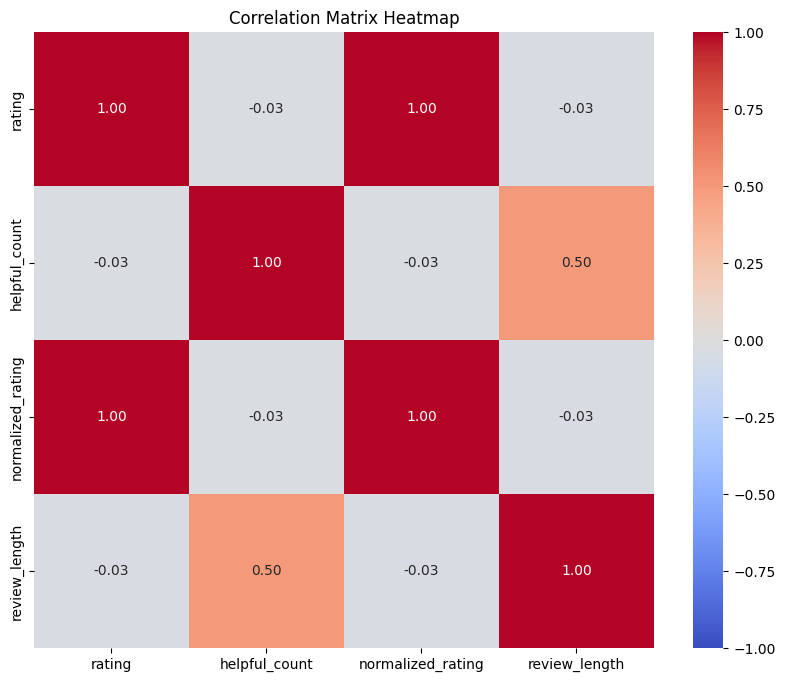

In [ ]:
# Create the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Correlation Matrix Heatmap")
plt.show()

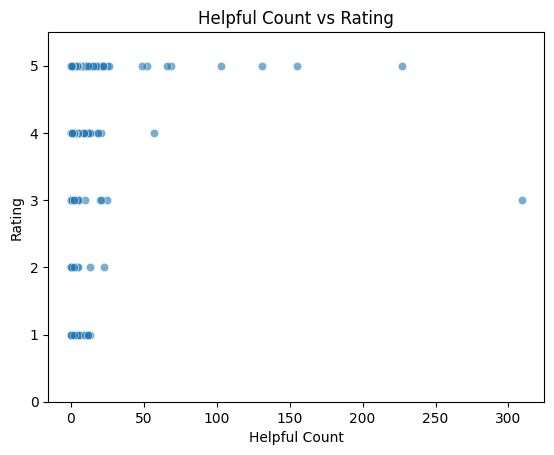

In [ ]:
sns.scatterplot(x="helpful_count", y="rating", data=df, alpha=0.6)
plt.title("Helpful Count vs Rating")
plt.xlabel("Helpful Count")
plt.ylabel("Rating")
plt.ylim(0, 5.5)
plt.show()

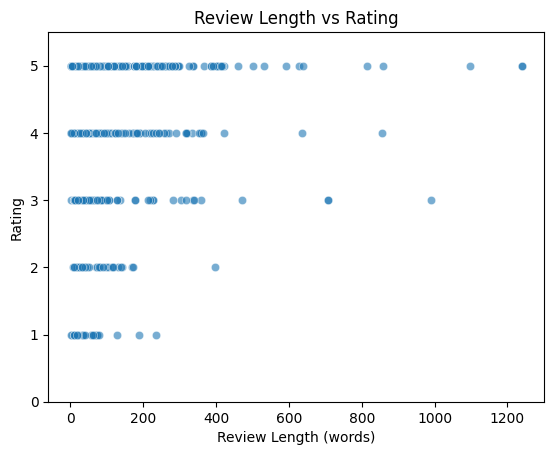

In [ ]:
sns.scatterplot(x="review_length", y="rating", data=df, alpha=0.6)
plt.title("Review Length vs Rating")
plt.xlabel("Review Length (words)")
plt.ylabel("Rating")
plt.ylim(0, 5.5)
plt.show()

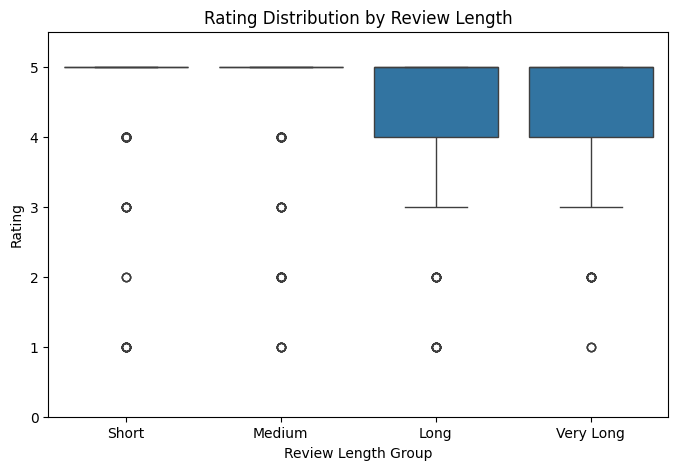

In [ ]:
# Showing the rating distribution as a box plot
df["review_length_group"] = pd.qcut(df["review_length"], q=4, labels=["Short", "Medium", "Long", "Very Long"])

plt.figure(figsize=(8, 5))
sns.boxplot(x="review_length_group", y="rating", data=df)
plt.title("Rating Distribution by Review Length")
plt.xlabel("Review Length Group")
plt.ylabel("Rating")
plt.ylim(0, 5.5)
plt.show()